In [12]:
import numpy as np
import matplotlib.pyplot as plt
import keras
import keras.applications
from keras import layers
from keras.datasets import cifar10
from keras.utils import to_categorical
import tensorflow as tf

batch_size = 32
img_size = (32, 32)

train_dataset, validation_dataset = keras.utils.image_dataset_from_directory(
    'Images/train',
    batch_size=batch_size,
    image_size=img_size,
    label_mode='categorical',
    validation_split=0.2,
    subset='both',
    seed=123
)

test_dataset = keras.utils.image_dataset_from_directory(
    'Images/test',
    batch_size=batch_size,
    image_size=img_size,
    label_mode='categorical'
)





Found 50000 files belonging to 10 classes.
Using 40000 files for training.
Using 10000 files for validation.
Found 10000 files belonging to 10 classes.


In [13]:
conv_base = keras.applications.vgg16.VGG16(
weights="imagenet",
include_top=False,
input_shape=(32, 32, 3))

In [14]:
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)
        features = conv_base.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

In [15]:
train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

1/1 [==============================] - 0s 44ms/step


2025-04-03 18:25:57.758042: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [40000]
	 [[{{node Placeholder/_0}}]]
2025-04-03 18:25:57.758176: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [40000]
	 [[{{node Placeholder/_0}}]]


1/1 [==============================] - 0s 44ms/step


2025-04-03 18:27:05.824164: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [10000]
	 [[{{node Placeholder/_4}}]]
2025-04-03 18:27:05.824277: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [10000]
	 [[{{node Placeholder/_4}}]]


1/1 [==============================] - 0s 44ms/step


2025-04-03 18:27:23.019532: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [10000]
	 [[{{node Placeholder/_4}}]]
2025-04-03 18:27:23.019675: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [10000]
	 [[{{node Placeholder/_4}}]]


1/1 [==============================] - 0s 28ms/step


In [24]:
inputs = keras.Input(shape=(1, 1, 512))
x = layers.Flatten()(inputs)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 1, 1, 512)]       0         
                                                                 
 flatten_4 (Flatten)         (None, 512)               0         
                                                                 
 dense_12 (Dense)            (None, 128)               65664     
                                                                 
 dense_13 (Dense)            (None, 64)                8256      
                                                                 
 dropout_4 (Dropout)         (None, 64)                0         
                                                                 
 dense_14 (Dense)            (None, 10)                650       
                                                                 
Total params: 74,570
Trainable params: 74,570
Non-trainable

In [25]:
callbacks = [
keras.callbacks.ModelCheckpoint(
filepath="feature_extraction.keras",
save_best_only=True,
monitor="val_loss")
]

history = model.fit(train_features, train_labels, epochs=10, batch_size=batch_size, validation_data=(val_features, val_labels), callbacks=callbacks)

Epoch 1/10
1250/1250 [==============================] - 1s 537us/step - loss: 1.9088 - accuracy: 0.3998 - val_loss: 1.2962 - val_accuracy: 0.5506
Epoch 2/10
1250/1250 [==============================] - 1s 512us/step - loss: 1.3360 - accuracy: 0.5307 - val_loss: 1.1896 - val_accuracy: 0.5944
Epoch 3/10
1250/1250 [==============================] - 1s 490us/step - loss: 1.2059 - accuracy: 0.5801 - val_loss: 1.1176 - val_accuracy: 0.6184
Epoch 4/10
1250/1250 [==============================] - 1s 485us/step - loss: 1.1134 - accuracy: 0.6141 - val_loss: 1.0945 - val_accuracy: 0.6294
Epoch 5/10
1250/1250 [==============================] - 1s 486us/step - loss: 1.0472 - accuracy: 0.6403 - val_loss: 1.0756 - val_accuracy: 0.6420
Epoch 6/10
1250/1250 [==============================] - 1s 478us/step - loss: 0.9857 - accuracy: 0.6600 - val_loss: 1.0763 - val_accuracy: 0.6433
Epoch 7/10
1250/1250 [==============================] - 1s 482us/step - loss: 0.9360 - accuracy: 0.6769 - val_loss: 1.0894 -

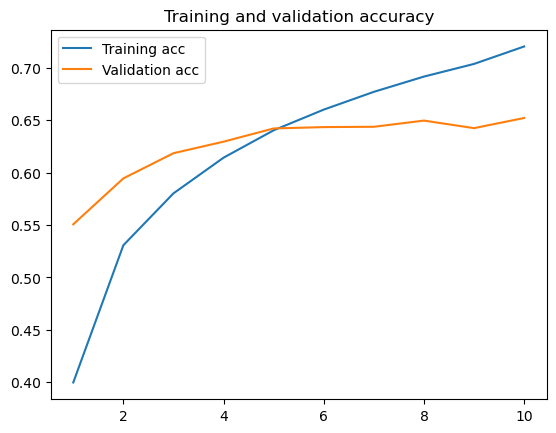

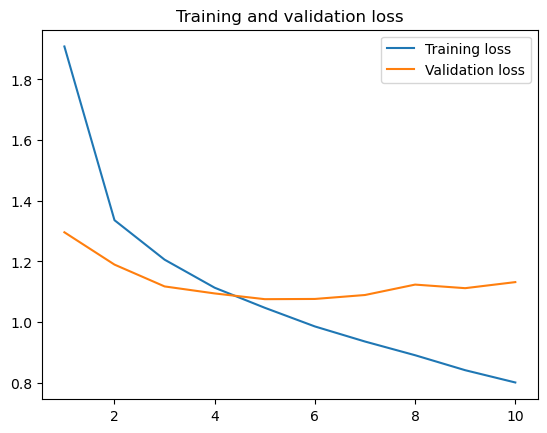

In [26]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [23]:
test_loss, test_accuracy = model.evaluate(test_features, test_labels)
print(f"Test accuracy: {test_accuracy}")
print(f"Test loss: {test_loss}")

313/313 [==============================] - 0s 266us/step - loss: 1.2541 - accuracy: 0.6393
Test accuracy: 0.6392999887466431
Test loss: 1.2540775537490845
